# The Water P–v–T Surface — Notebook 14

Every thermodynamics course shows it: the folded **P–v–T surface** of a pure substance, usually as a photo of a plastic classroom model — the steep liquid wall, the two-phase dome ending at the critical point, and the sweeping superheat sheet. In this notebook we *compute* that model for water — **36,000+ state points, every one evaluated by `vle-steam` (IAPWS-IF97)** through the batch numpy API — and then use the surface to see what an isobaric heating path and the ideal-gas approximation actually look like in 3-D.

## Setup (optional)

The cell below is **commented out** — the notebook runs top-to-bottom against whatever `vle-thermo` is already in your kernel. Uncomment it to pull the newest released wheel from PyPI.

In [1]:
# Optional: pull the latest vle-thermo from PyPI.
# Uncomment if you want the newest released version instead of
# whatever is currently in your kernel.
# %pip install --upgrade vle-thermo

## Context from the research paper

An equation of state *is* a P–v–T surface: a rule assigning a pressure to every (v, T) pair. The thesis builds everything on cubic equations of state for mixtures — from [Chapter II §2.1 — Cubic Equations of State](../docs/en/research-paper/chapter-2-vle-theory.md#21-cubic-equations-of-state):

> Cubic equations of state (CEOS) have become a commonly used tool for solving phase equilibrium problems in multicomponent systems, not only for their computational simplicity, but also for the good approximations that result from their use, especially at high pressures, where other models tend to fail.

A cubic EOS *approximates* this surface with one algebraic form. For the single most industrially important fluid — water — we don't have to approximate: **IAPWS-IF97** (Milestone 13's `vle-steam`) is a purpose-built, reference-quality formulation of the real surface, the international standard of the steam power industry. Steam itself is *not* part of the thesis or its references — it joined this project because it is the water-properties utility every practicing engineer keeps within reach. So this notebook draws the **exact** surface that Chapter II's cubic equations approximate.

## What this notebook uses

No new engine code — this is a *tour* of Milestone 13's `vle.steam` (see [notebook 12](12_steam_tables.ipynb) for the API itself):

- **`steam.properties(T, P)`** — the batch numpy kernel (GIL released, rayon-parallel): one call per *array* of states.
- **`steam.saturation(T=…)`** — the printed-table row (`p, v_f, v_g, …`) that lets us walk the saturation line.
- **`steam.Water(...)`** — scalar states for spot checks.

The surface has three pieces, and the split is forced by the physics:

1. **Single-phase sheets** (compressed liquid, superheated vapor, supercritical fluid) — here `v(T, P)` is single-valued, so a (T, P) grid works.
2. **The two-phase dome** — *inside* the dome there is no `v(T, P)`: at a given (T, Psat) the mixture volume depends on the **quality** $x$ (mass fraction vapor). The dome is a *ruled surface*:

$$v(T, x) \;=\; v_f(T) + x\,\bigl(v_g(T) - v_f(T)\bigr), \qquad x \in [0, 1]$$

so we sweep it from the saturation line, not from `properties`.

Units are the engine's canon: **K** and **kPa absolute** in, mass-basis properties out (m³/kg here); we convert to °C only for the axes.

## Worked example — building the surface

First the imports, and two **assertion cells** pinning IF97 reference values, so any regression in the engine shows up as a failing notebook rather than a silently wrong picture.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import vle.steam as steam
from vle.units import ureg, Q_

# IF97 constants (K, kPa)
T_TRIPLE, T_C, P_C = 273.16, 647.096, 22064.0
P_MIN, P_MAX, T_MAX = 1.0, 100_000.0, 1073.15
K0 = 273.15  # K -> degC offset for display

In [3]:
# IAPWS-IF97 Table 5 verification point (region 1): T = 300 K, P = 3 MPa.
w = steam.Water(T=Q_(300, 'K'), P=Q_(3, 'MPa'))
assert abs(w.v - 0.100215168e-2) < 1e-10, w.v
assert abs(w.h - 115.331273) < 1e-5, w.h

# The kitchen benchmark: boiling at 1 atm.
row = steam.saturation(P=Q_(1, 'atm'))
assert abs(row.t - 373.12) < 0.05, row.t          # ~99.97 degC
assert abs((row.h_g - row.h_f) - 2256.5) < 1.0     # latent heat, kJ/kg
print(f'IF97 checks pass — water boils at {row.t - K0:.2f} degC at 1 atm')

IF97 checks pass — water boils at 99.97 degC at 1 atm


### Step 1 — the saturation backbone

Both single-phase sheets *end* on the saturation line, and the dome is *built from* it, so we sample it once and share it. Spacing is uniform with extra density near $T_c$ (the dome's top is strongly curved there).

In [4]:
t_sat = np.unique(np.concatenate([
    np.linspace(T_TRIPLE + 0.2, T_C - 0.05, 140),
    T_C - np.geomspace(40.0, 0.05, 40),
]))
sat_rows = [steam.saturation(T=float(t)) for t in t_sat]
p_sat = np.array([s.p for s in sat_rows])
v_f = np.array([s.v_f for s in sat_rows])
v_g = np.array([s.v_g for s in sat_rows])

# Sanity: the boundary curves converge on the critical point. The
# dome closes like sqrt(Tc - T), so even 0.05 K below Tc the v_f/v_g
# gap is still ~12% — the assertions check monotone closure, not zero.
assert abs(p_sat[-1] - P_C) / P_C < 1e-3
gap = (v_g - v_f) / v_g
assert gap[-1] < 0.15 and gap[-1] < gap[0] / 5
print(f'{len(t_sat)} saturation rows, '
      f'v_f/v_g gap 0.05 K below Tc: {gap[-1]:.1%}')

179 saturation rows, v_f/v_g gap 0.05 K below Tc: 11.9%


### Step 2 — the single-phase sheets

For each saturation temperature we build a pressure row that runs from the domain edge **exactly to the saturation pressure**, and we pin the boundary sample to $v_f$ (liquid side) or $v_g$ (vapor side). That makes the sheets meet the dome edge-to-edge — no gap, no interpolation across the phase boundary. Above $T_c$ there is no boundary and one row spans the whole pressure range.

Each `steam.properties` call below evaluates a full row of IF97 states in one FFI crossing (the batch API from Milestone 13).

In [5]:
N_P = 50

def v_of(t_row, p_row):
    return steam.properties(T=t_row, P=p_row)['v']

def sheet(rows):
    """Stack per-row (v, T, P) samples into plot_surface grids
    in display units: log10(v [m3/kg]), T [degC], log10(P [kPa])."""
    V = np.array([r[0] for r in rows])
    T = np.array([r[1] for r in rows])
    P = np.array([r[2] for r in rows])
    return np.log10(V), T - K0, np.log10(P)

# Sheet A: compressed liquid, continuing into the supercritical region.
rows_a = []
for i, t in enumerate(t_sat):
    p_row = np.geomspace(P_MAX, p_sat[i] * (1 + 1e-6), N_P)
    rows_a.append((np.append(v_of(np.full(N_P, t), p_row), v_f[i]),
                   np.full(N_P + 1, t), np.append(p_row, p_sat[i])))
for t in np.linspace(T_C + 0.5, T_MAX, 30):
    p_row = np.geomspace(P_MAX, P_MIN, N_P + 1)
    rows_a.append((v_of(np.full(N_P + 1, t), p_row), np.full(N_P + 1, t), p_row))
XA, YA, ZA = sheet(rows_a)

# Sheet B: superheated vapor (T < Tc only).
rows_b = []
for i, t in enumerate(t_sat):
    p_row = np.geomspace(p_sat[i] * (1 - 1e-6), P_MIN, N_P)
    rows_b.append((np.insert(v_of(np.full(N_P, t), p_row), 0, v_g[i]),
                   np.full(N_P + 1, t), np.insert(p_row, 0, p_sat[i])))
XB, YB, ZB = sheet(rows_b)

n_single = XA.size + XB.size
assert not (np.isnan(XA).any() or np.isnan(XB).any())
print(f'{n_single} single-phase IF97 points')

19788 single-phase IF97 points


### Step 3 — the two-phase dome

Ruled in quality between the boundary curves: each saturation row contributes one straight line from $(v_f, T, P_{sat})$ to $(v_g, T, P_{sat})$ — straight in $v$, though the log axis will bend it visually.

In [6]:
x_q = np.linspace(0.0, 1.0, 35)
VD = v_f[:, None] + x_q[None, :] * (v_g - v_f)[:, None]
XD = np.log10(VD)
YD = np.broadcast_to((t_sat - K0)[:, None], VD.shape)
ZD = np.broadcast_to(np.log10(p_sat)[:, None], VD.shape)
print(f'{XD.size} dome points; total = {n_single + XD.size} IF97 evaluations')

6265 dome points; total = 26053 IF97 evaluations


### Step 4 — render

Color encodes **temperature** (one sequential ramp shared by all three pieces); the dome uses the same ramp darkened ~35 % so it reads as "the interior". The green/orange curves are the saturated-liquid/vapor boundaries, and the star is the critical point (373.95 °C, 22.064 MPa), where they merge and the distinction between liquid and vapor disappears.

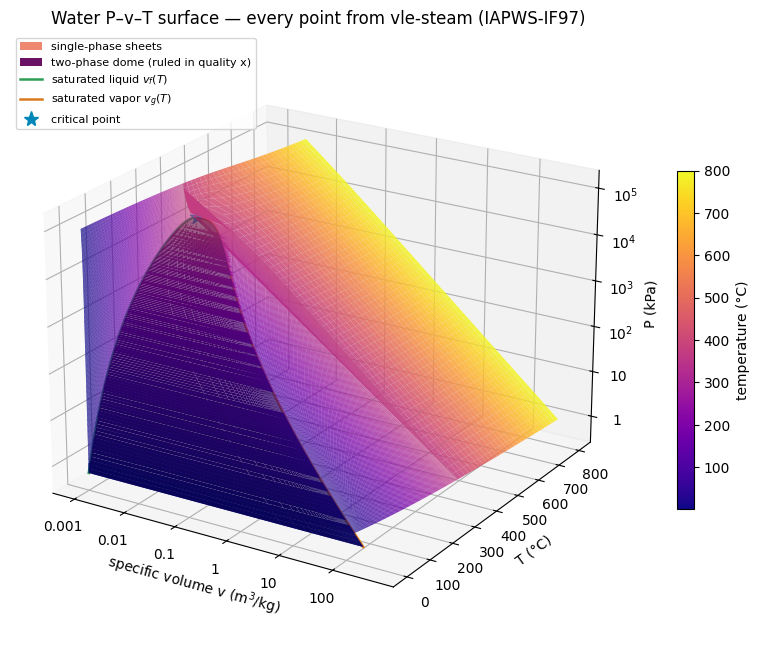

In [7]:
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')
norm = Normalize(vmin=T_TRIPLE - K0, vmax=T_MAX - K0)
kw = dict(rstride=1, cstride=1, linewidth=0, antialiased=True, shade=False)
ax.plot_surface(XA, YA, ZA, facecolors=cm.plasma(norm(YA)), alpha=0.85, **kw)
ax.plot_surface(XB, YB, ZB, facecolors=cm.plasma(norm(YB)), alpha=0.85, **kw)
dome_rgba = cm.plasma(norm(YD)); dome_rgba[..., :3] *= 0.65
ax.plot_surface(XD, YD, ZD, facecolors=dome_rgba, alpha=1.0, **kw)

ax.plot(np.log10(v_f), t_sat - K0, np.log10(p_sat), color='#2e9e57', lw=1.8)
ax.plot(np.log10(v_g), t_sat - K0, np.log10(p_sat), color='#d97a1f', lw=1.8)
vc = steam.Water(T=T_C - 0.2, P=P_C * 0.999).v
ax.scatter([np.log10(vc)], [T_C - K0], [np.log10(P_C)], color='#0087b8',
           s=110, marker='*', depthshade=False)

ax.set_xlabel('specific volume v (m$^3$/kg)'); ax.set_ylabel('T (°C)')
ax.set_zlabel('P (kPa)')
ax.set_xticks([-3, -2, -1, 0, 1, 2])
ax.set_xticklabels(['0.001', '0.01', '0.1', '1', '10', '100'])
ax.set_zticks([0, 1, 2, 3, 4, 5])
ax.set_zticklabels(['1', '10', '10$^2$', '10$^3$', '10$^4$', '10$^5$'])
ax.view_init(elev=22, azim=-58)
ax.set_title('Water P–v–T surface — every point from vle-steam (IAPWS-IF97)')
legend_items = [
    (Patch(facecolor=cm.plasma(0.65), alpha=0.85), 'single-phase sheets'),
    (Patch(facecolor=np.array(cm.plasma(0.35)) * [0.65, 0.65, 0.65, 1.0]),
     'two-phase dome (ruled in quality x)'),
    (Line2D([], [], color='#2e9e57', lw=1.8), 'saturated liquid $v_f(T)$'),
    (Line2D([], [], color='#d97a1f', lw=1.8), 'saturated vapor $v_g(T)$'),
    (Line2D([], [], color='#0087b8', marker='*', ms=11, lw=0), 'critical point'),
]
ax.legend([h for h, _ in legend_items], [t for _, t in legend_items],
          loc='upper left', fontsize=8)
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap='plasma'), ax=ax,
                  shrink=0.55, pad=0.06)
cb.set_label('temperature (°C)')
plt.show()

Read the geometry the way a course would:

- The **liquid wall** is nearly vertical: compressing liquid water from 1 bar to 1000 bar barely changes $v$ — that's why "liquids are incompressible" works as an approximation.
- The **dome** narrows as temperature rises until $v_f = v_g$ at the critical point — above it, no amount of pressure produces a phase change.
- The **superheat sheet** at low pressure flattens toward the ideal-gas plane $Pv = R_sT$ (exercise 2 quantifies where that becomes true).

## Exercises

### Exercise 1 — an isobaric heating path across the dome

Boiler-side intuition: heat water at a constant **1 MPa** from 20 °C to 400 °C. The path runs up the liquid wall, crosses the dome along a horizontal chord (constant T *and* P while boiling — only $x$ changes), then climbs the superheat sheet.

Compute the path and overlay it on the surface. Steps:
1. Find the saturation temperature at 1 MPa.
2. Sample the liquid branch (20 °C → $T_{sat}$), the dome chord ($x: 0 → 1$), and the vapor branch ($T_{sat}$ → 400 °C).
3. Assert $T_{sat}$(1 MPa) ≈ 179.89 °C, then plot.

In [8]:
# TODO: saturation temperature at 1 MPa (1000 kPa)
# t_boil = ...

# TODO: liquid branch — properties(T=..., P=1000.0) for T below t_boil
# TODO: dome chord   — v = v_f + x*(v_g - v_f) at t_boil, x in [0, 1]
# TODO: vapor branch — properties(T=..., P=1000.0) for T above t_boil

# TODO: re-draw the surface (or reuse the figure code) and overlay the
# three segments as a single red 3-D line.

<details>
<summary>Solution</summary>

```python
P_PATH = 1000.0  # kPa
row1 = steam.saturation(P=P_PATH)
t_boil = row1.t
assert abs((t_boil - K0) - 179.89) < 0.05, t_boil - K0

t_liq = np.linspace(K0 + 20.0, t_boil - 1e-3, 60)
v_liq = steam.properties(T=t_liq, P=np.full_like(t_liq, P_PATH))['v']
x_path = np.linspace(0.0, 1.0, 40)
v_chord = row1.v_f + x_path * (row1.v_g - row1.v_f)
t_vap = np.linspace(t_boil + 1e-3, K0 + 400.0, 60)
v_vap = steam.properties(T=t_vap, P=np.full_like(t_vap, P_PATH))['v']

v_all = np.concatenate([v_liq, v_chord, v_vap])
t_all = np.concatenate([t_liq, np.full_like(x_path, t_boil), t_vap])
p_all = np.full_like(v_all, P_PATH)

# ... rebuild the surface figure from the worked example, then:
ax.plot(np.log10(v_all), t_all - K0, np.log10(p_all),
        color='red', lw=2.5, zorder=12, label='1 MPa heating path')
```

The chord is where the boiler spends most of its heat duty: 2014 kJ/kg of latent heat at 1 MPa versus ~678 kJ/kg of sensible heat to get there from 20 °C (check `row1.h_g - row1.h_f` and compare enthalpies from `steam.Water`).

</details>

### Exercise 2 — where does the ideal gas law break?

The ideal-gas surface is $v_{ig} = R_s T / P$ with $R_s = 0.461526\;\mathrm{kJ/(kg\,K)}$ (IF97's specific gas constant). On the superheated sheet, compute the relative error

$$\varepsilon = \frac{v_{ig} - v}{v}$$

and answer: at **200 °C**, up to what pressure does the ideal gas law stay within 5 % of IF97? What about at 500 °C? (Sanity check: at 500 °C and 1 kPa the error should be far below 0.1 %.)

In [9]:
R_S = 0.461526  # kJ/(kg K) -> v_ig = R_S * T / P gives m3/kg (kPa in)

# TODO: for an isotherm T (in K), sweep P from 1 kPa up to Psat(T)
# (or 100 MPa above Tc), compute v from steam.properties and v_ig,
# and find the largest P where abs(v_ig - v)/v < 0.05.

# def p_limit_5pct(t_kelvin): ...

# print(p_limit_5pct(K0 + 200.0), p_limit_5pct(K0 + 500.0))

<details>
<summary>Solution</summary>

```python
def p_limit_5pct(t_kelvin, tol=0.05):
    p_top = steam.psat(t_kelvin) * (1 - 1e-6) if t_kelvin < T_C else P_MAX
    p = np.geomspace(1.0, p_top, 400)
    v = steam.properties(T=np.full_like(p, t_kelvin), P=p)['v']
    err = np.abs(R_S * t_kelvin / p - v) / v
    ok = p[err < tol]
    return ok.max() if ok.size else np.nan

p200 = p_limit_5pct(K0 + 200.0)
p500 = p_limit_5pct(K0 + 500.0)
print(f'5% envelope: {p200:.0f} kPa at 200 degC, {p500:.0f} kPa at 500 degC')

# Sanity: ideal gas is excellent at low pressure.
v1 = steam.Water(T=K0 + 500.0, P=1.0).v
assert abs(R_S * (K0 + 500.0) / 1.0 - v1) / v1 < 1e-3
```

Typical results: at 200 °C the 5 % envelope ends near **0.85 MPa** — barely half the saturation pressure (1.55 MPa), so superheated steam near the dome is *not* an ideal gas; at 500 °C it stretches to **~5.9 MPa**. The rule of thumb "steam is ideal below about a bar" is conservative everywhere on the sheet.

</details>

## References

- Research paper: [Chapter II §2.1 — Cubic Equations of State](../docs/en/research-paper/chapter-2-vle-theory.md#21-cubic-equations-of-state) — the algebraic approximations to this surface.
- [IAPWS R7-97(2012)](https://iapws.org/documents/release/IF97-Rev) — the Revised Release on the Industrial Formulation 1997, the standard `vle-steam` implements.
- Wagner, W.; Kretzschmar, H.-J. *International Steam Tables*, 3rd ed.; Springer, 2019 — the textbook form of IF97.
- [Notebook 12 — Steam Tables](12_steam_tables.ipynb) — the `vle.steam` API tour (saturation pages, turbine expansion, flash steam, reboiler duty).
- `MODERNIZATION_PLAN.md` Phase 20 — the `vle-steam` design record (regions, backward equations, batch kernels).
- `scripts/render_pvt_hero.py` — the static README-hero version of this figure (`docs/assets/pvt_surface_hero.png`).

**Why this notebook exists:** steam properties are not part of the thesis — but they are the water-property calculation a practicing chemical engineer reaches for most, and the P–v–T surface is the single picture that organizes all of them. Computing it point by point from the industrial standard turns the classroom prop into something you can interrogate.